In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid");

In [13]:
df=pd.read_csv("data/netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [34]:
df.shape

(8807, 13)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [35]:
df['director']=df['director'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')
df['rating']=df['rating'].fillna('Not Rated')

In [36]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      10
dtype: int64

In [25]:
df['date_added'] = df['date_added'].str.strip()

In [26]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [27]:
df['year_added'] = df['date_added'].dt.year

In [ ]:
*** EDA 

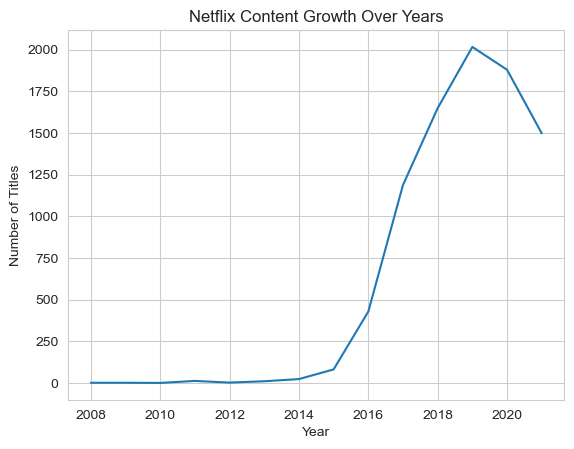

In [28]:
df['year_added'].value_counts().sort_index().plot()

plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.savefig("images/netflix_growth.png", bbox_inches="tight")
plt.show()

*** Insight: Netflix Growth   **
    
- Netfilx content increased rapidly after 2016.
- The platform reached its peak content addition around 2019.
- The slight drop after 2020 may reflect production slowdowns or strategic shifts.
    

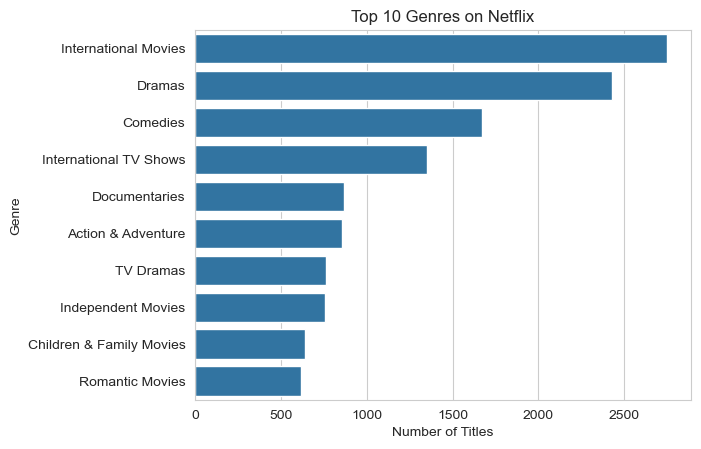

In [31]:
genres = df['listed_in'].str.split(', ', expand=True).stack()

top_genres = genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.savefig("images/top_genres.png", bbox_inches="tight")
plt.show()

*** Insight: Genres 

-International movies were the top genres on Netfilx followed by Dramas and Comedies.

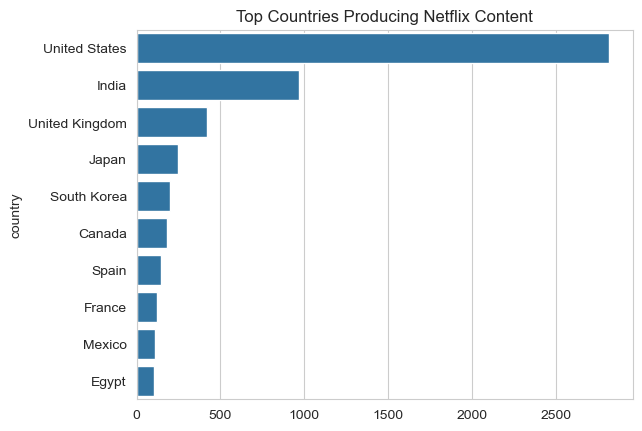

In [32]:
top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries Producing Netflix Content")
plt.savefig("images/top_countries.png", bbox_inches="tight")
plt.show()

### Insight: Content Production by Country

- The United States produces the highest number of titles on Netflix.
- India and the United Kingdom  are also major contributors.

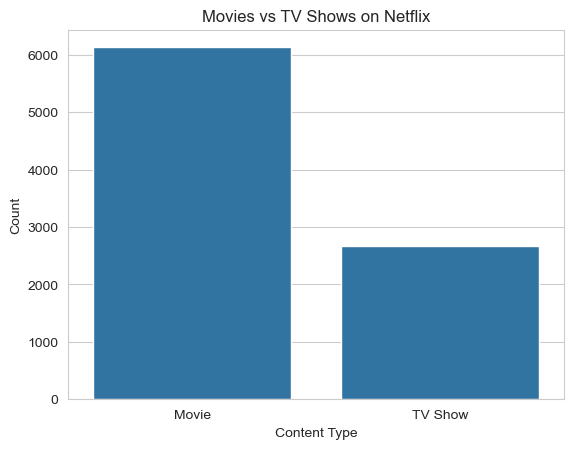

In [37]:
sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.savefig("images/movies_vs_tvshows.png",bbox_inches="tight")

plt.show()

*** Insight: Content Type Distribution

- Movies dominate the Netflix platform compared to TV Shows.
- This suggests Netflix focuses heavily on film content.

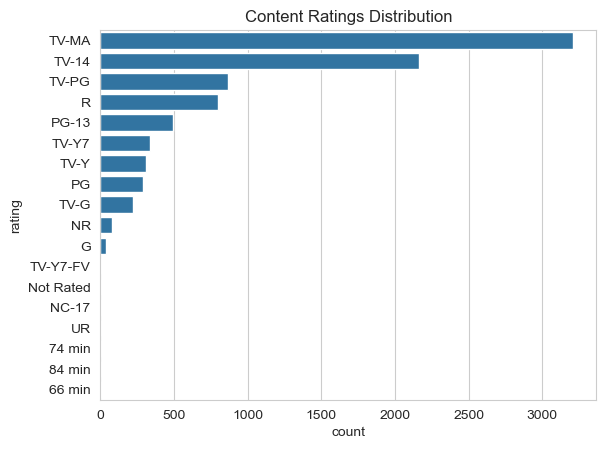

In [39]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)

plt.title("Content Ratings Distribution")
plt.savefig("images/rating_distribution.png", bbox_inches="tight")

plt.show()

*** Insight:Rating Distribution

- TV-MA is the highest rated content followed by TV-14.

In [18]:

movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min','')

movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

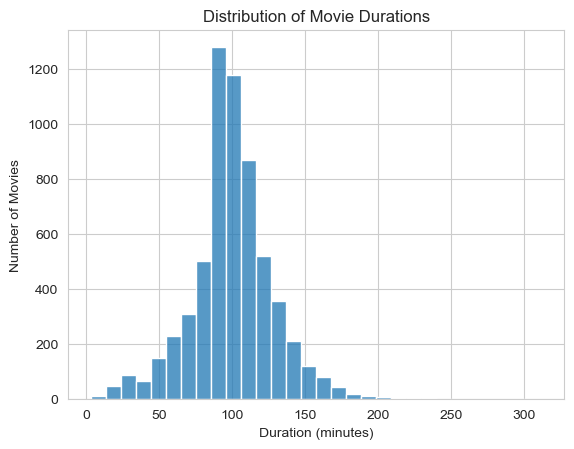

In [40]:
sns.histplot(movies['duration'], bins=30)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.savefig("images/movie_duration.png", bbox_inches="tight")
plt.show()

*** Insight: Movie Duration

Most Netflix movies fall between 80–120 minutes, indicating standard feature-length films.

In [22]:
movies['duration'].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

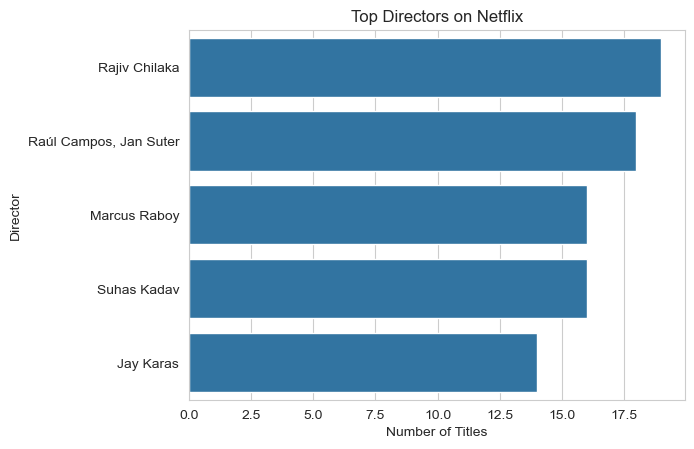

In [44]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(5)

sns.barplot(x=top_directors.values, y=top_directors.index)

plt.title("Top Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

### Insight: Director Contributions

- Several directors appear multiple times on Netflix, indicating recurring collaborations.
- Directors such as Raúl Campos and Marcus Raboy  have directed multiple Netflix titles.
- This suggests that Netflix often works repeatedly with certain creators.

## Conclusion

Key findings from the Netflix dataset:

- Netflix content grew rapidly after 2016.
- The United States produces the highest number of titles.
- Movies dominate the platform compared to TV Shows.
- Most Netflix movies are between 80–120 minutes long.
- International Movies, Dramas, and Comedies are the most common genres.